# Ames Housing Data Exploration

House Prices: Advanced Regression Techniques
Kaggle Competition - Complete Machine Learning Pipeline

This notebook provides a comprehensive end-to-end solution for predicting house prices, covering data exploration, preprocessing, feature engineering, multiple model training, and final predictions.

---
## 1. Data Loading and Initial Overview
---

Let's start by importing the necessary libraries and loading our data.

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Advanced Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Settings
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# ==============================================================================
#  LOAD DATA
# ==============================================================================

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

# Load training and test datasets

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Save test IDs for final submission
# We do this NOW because we'll drop the Id column during preprocessing
# and need to keep track of which prediction belongs to which house
test_ids = test['Id'].copy()

print(f"✓ Train shape: {train.shape}")
print(f"✓ Test shape: {test.shape}")
print(f"\nFirst few rows of training data:")
print(train.head())


LOADING DATA
✓ Train shape: (1460, 81)
✓ Test shape: (1459, 80)

First few rows of training data:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN  

In [3]:
# Basic info
print("\nTrain Dataset Info:")
print(train.info())

print("\nTrain Dataset Statistics:")
print(train.describe())


Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

**Initial Observations:**

- Training set has 1,460 houses with 81 columns
- Mix of numerical (38) and categorical (43) features
- Several features have missing values (to be addressed later)

---
## 2. Exploratory Data Analysis (EDA)
---
Before preprocessing, we need to understand our data and target variable.

### 2.1 Target Variable Distribution - SalePrice

Understanding the distribution of **SalePrice** is crucial because:
- It helps us decide if we need to transform the target
- Skewed distributions can hurt model performance (especially linear models)
- We want to check for outliers

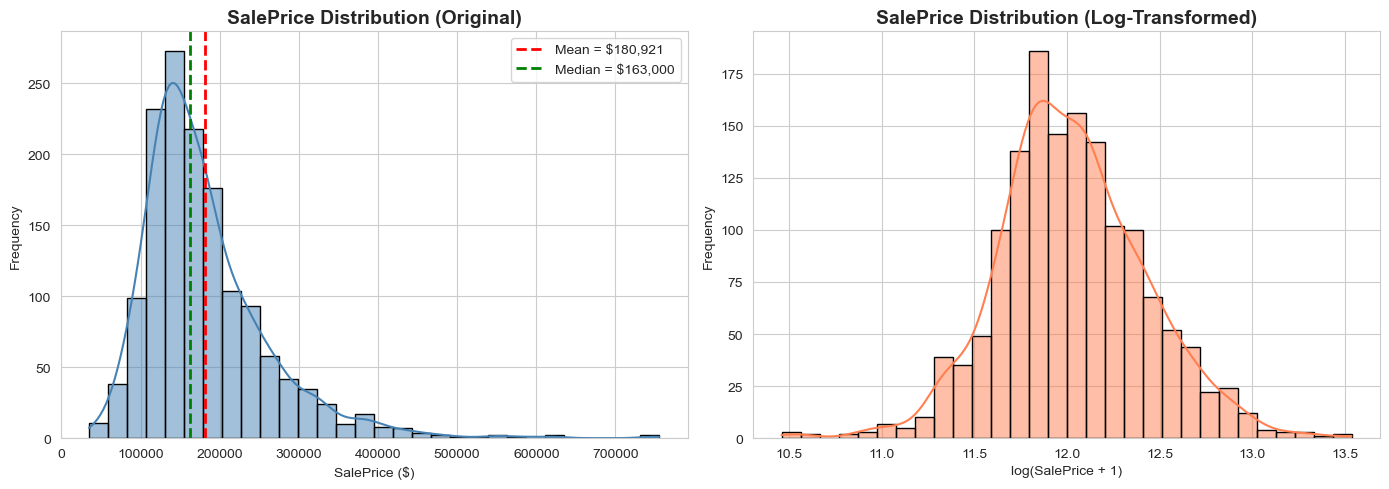

SALEPRICE STATISTICS
Min:      $      34,900
Max:      $     755,000
Mean:     $  180,921.20
Median:   $  163,000.00
Std Dev:  $   79,442.50

Skewness (original):        1.88
Skewness (log-transformed): 0.12


In [4]:
# Visualize SalePrice distribution
plt.figure(figsize=(14, 5))

# Original distribution
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, bins=30, color='steelblue', edgecolor='black')
plt.axvline(train['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = ${train["SalePrice"].mean():,.0f}')
plt.axvline(train['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Median = ${train["SalePrice"].median():,.0f}')
plt.title('SalePrice Distribution (Original)', fontsize=14, fontweight='bold')
plt.xlabel('SalePrice ($)')
plt.ylabel('Frequency')
plt.legend()

# Log-transformed distribution
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['SalePrice']), kde=True, bins=30, color='coral', edgecolor='black')
plt.title('SalePrice Distribution (Log-Transformed)', fontsize=14, fontweight='bold')
plt.xlabel('log(SalePrice + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Statistics
print("=" * 60)
print("SALEPRICE STATISTICS")
print("=" * 60)
print(f"Min:      ${train['SalePrice'].min():>12,}")
print(f"Max:      ${train['SalePrice'].max():>12,}")
print(f"Mean:     ${train['SalePrice'].mean():>12,.2f}")
print(f"Median:   ${train['SalePrice'].median():>12,.2f}")
print(f"Std Dev:  ${train['SalePrice'].std():>12,.2f}")
print(f"\nSkewness (original):        {train['SalePrice'].skew():.2f}")
print(f"Skewness (log-transformed): {np.log1p(train['SalePrice']).skew():.2f}")

**📈 Key Findings:**

- **Skewness = 1.88** → Distribution is **right-skewed** (long tail on the right)
- **Mean > Median** → Confirms right-skew (mean pulled by expensive houses)
- **Range:** $34,900 to $755,000 → Wide price variation

**Why Log Transform?**

**Problem with right-skewed data:**
- Linear models assume normally distributed residuals
- Skewed data leads to poor predictions (especially at extremes)
- A few very expensive houses can dominate the model

**Solution: Log Transformation**
- `log1p(SalePrice)` normalizes the distribution (skewness closer to 0)
- After log transform: skewness = 1.88 (much closer to 0 = normal)
- Models learn patterns better on normalized data

**Note:** We use `log1p()` (log(x+1)) instead of `log()` to handle potential zeros safely.

**Decision:** We will train models on **log-transformed SalePrice**, then convert predictions back using `expm1()`.

---
## 4.  Data Preprocessing & Feature Engineering
---

### 4.1 Missing Values Analysis

Let's create a function to analyze missing values and apply it to both train and test sets.

In [5]:
def analyze_missing(df, dataset_name="Dataset"):
    """
    Analyze and display missing values in a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe to analyze
    dataset_name : str
        Name of the dataset for display purposes
        
    Returns:
    --------
    pandas.DataFrame
        Table with missing value counts and percentages
    """
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print(f"✓ No missing values in {dataset_name}")
        return None
    
    missing_pct = (missing / len(df) * 100).round(2)
    
    missing_df = pd.DataFrame({
        "Missing Count": missing,
        "Percentage (%)": missing_pct
    })
    
    print("=" * 60)
    print(f"MISSING VALUES IN {dataset_name.upper()}")
    print("=" * 60)
    print(missing_df)
    print(f"\nTotal features with missing values: {len(missing_df)}")
    
    return missing_df


In [6]:
# Analyze missing values
train_missing = analyze_missing(train, "Training Set")
test_missing = analyze_missing(test, "Test Set")

MISSING VALUES IN TRAINING SET
              Missing Count  Percentage (%)
PoolQC                 1453           99.52
MiscFeature            1406           96.30
Alley                  1369           93.77
Fence                  1179           80.75
MasVnrType              872           59.73
FireplaceQu             690           47.26
LotFrontage             259           17.74
GarageType               81            5.55
GarageYrBlt              81            5.55
GarageFinish             81            5.55
GarageQual               81            5.55
GarageCond               81            5.55
BsmtFinType2             38            2.60
BsmtExposure             38            2.60
BsmtFinType1             37            2.53
BsmtCond                 37            2.53
BsmtQual                 37            2.53
MasVnrArea                8            0.55
Electrical                1            0.07

Total features with missing values: 19
MISSING VALUES IN TEST SET
              Missing 

### 4.2 Handle Missing Values in Categorical columns (NaN = "None")

For features like PoolQC, Garage, Basement, etc., NaN means the feature doesn't exist (e.g., no pool, no garage).
We replace NaN with "None" to indicate absence.

In [7]:
# ----------------- Handle Categorical NaN (NaN = "None" = Absence) -----------------
print("\n1. Replacing NaN with 'None' for categorical features (NaN = Absence)...")

cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu'
]

for col in cols_none:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

print(f"✓ Replaced NaN with 'None' for {len(cols_none)} categorical columns")


1. Replacing NaN with 'None' for categorical features (NaN = Absence)...
✓ Replaced NaN with 'None' for 15 categorical columns


### 4.3 Impute Numerical Features

Before imputing, let's visualize the distribution of **LotFrontage** to choose the appropriate strategy.

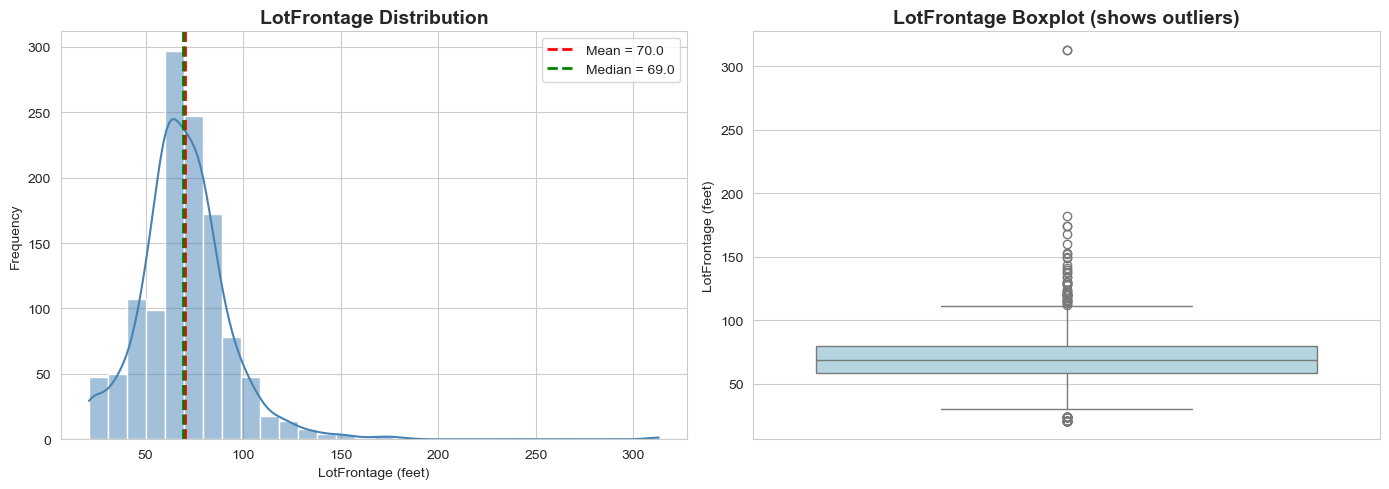

Mean:     70.05 feet
Median:   69.00 feet
Skewness: 2.16
Missing:  259 values (17.7%)


In [8]:
# Visualize LotFrontage distribution
plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(train['LotFrontage'].dropna(), kde=True, bins=30, color='steelblue')
plt.axvline(train['LotFrontage'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {train["LotFrontage"].mean():.1f}')
plt.axvline(train['LotFrontage'].median(), color='green', linestyle='--', linewidth=2, label=f'Median = {train["LotFrontage"].median():.1f}')
plt.title('LotFrontage Distribution', fontsize=14, fontweight='bold')
plt.xlabel('LotFrontage (feet)')
plt.ylabel('Frequency')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=train['LotFrontage'].dropna(), color='lightblue')
plt.title('LotFrontage Boxplot (shows outliers)', fontsize=14, fontweight='bold')
plt.ylabel('LotFrontage (feet)')

plt.tight_layout()
plt.show()

# Statistics
print(f"Mean:     {train['LotFrontage'].mean():.2f} feet")
print(f"Median:   {train['LotFrontage'].median():.2f} feet")
print(f"Skewness: {train['LotFrontage'].skew():.2f}")
print(f"Missing:  {train['LotFrontage'].isnull().sum()} values ({train['LotFrontage'].isnull().sum()/len(train)*100:.1f}%)")

**Observations:**

- **Skewness = 2.16** (positive) → Distribution is **right-skewed**
- **Mean (70.05) ≈ Median (69.00)** → Very close, but skewness confirms outliers present
- **Outliers present** → Boxplot shows houses with very large lot frontage (200+ feet)

**Why use MEDIAN instead of MEAN?**

Even though mean and median are close (70 vs 69 feet), the **skewness of 2.16** confirms the distribution has a long right tail with outliers.

- **Median** is robust to outliers
- **Mean** can be influenced by extreme values (even if slightly)
- **Best practice:** Use median for skewed distributions (skewness > 1)

**Visual Evidence:**

The histogram shows:
- Most houses concentrated between 50-80 feet
- Long right tail extending to 313 feet
- Mean and median are close, but skewness indicates asymmetry

The boxplot clearly shows:
- **Dozens of outliers** above 110 feet
- One extreme outlier at **313 feet**!
- Median (69) represents the **typical house**
- Mean (70) is slightly pulled by outliers

**Conclusion:** Median is the safer choice for imputation, as it represents the central tendency without being influenced by extreme values.
**Decision:** Use **median = 69 feet** to impute missing LotFrontage values.

In [9]:
# Impute with median (robust to right-skewed distribution)
median_lf = train['LotFrontage'].median()
train['LotFrontage'] = train['LotFrontage'].fillna(median_lf)
test['LotFrontage'] = test['LotFrontage'].fillna(median_lf)

print(f"✓ LotFrontage: Filled {train['LotFrontage'].isnull().sum() + test['LotFrontage'].isnull().sum()} missing values with median ({median_lf:.1f} feet)")

✓ LotFrontage: Filled 0 missing values with median (69.0 feet)


**Other Numerical Features:**

Now let's handle the remaining numerical missing values with appropriate strategies.

In [10]:
# GarageYrBlt: Logical assumption: garage built same year as house, use YearBuilt
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(test['YearBuilt'])

print("✓ GarageYrBlt: Filled with YearBuilt (logical assumption)")

✓ GarageYrBlt: Filled with YearBuilt (logical assumption)


In [11]:
# MasVnrArea: Conditional imputation based on MasVnrType
# If no masonry veneer → 0, otherwise → median of houses WITH masonry

train.loc[(train['MasVnrType'] == 'None') & (train['MasVnrArea'].isna()), 'MasVnrArea'] = 0
test.loc[(test['MasVnrType'] == 'None') & (test['MasVnrArea'].isna()), 'MasVnrArea'] = 0

median_mv = train.loc[train['MasVnrType'] != 'None', 'MasVnrArea'].median()
train.loc[(train['MasVnrType'] != 'None') & (train['MasVnrArea'].isna()), 'MasVnrArea'] = median_mv
test.loc[(test['MasVnrType'] != 'None') & (test['MasVnrArea'].isna()), 'MasVnrArea'] = median_mv

print(f"✓ MasVnrArea: Filled conditionally (0 if None, else median = {median_mv:.1f})")

✓ MasVnrArea: Filled conditionally (0 if None, else median = 202.5)


### 4.4 Impute Remaining Features (Train & Test)

**Train set:** Electrical has 1 missing value → fill with **mode**

**Test set:** 
- Categorical features → fill with **mode** (most frequent value)
- Numerical features → fill with **median**

In [12]:
# Train: Electrical (only 1 missing)
mode_electrical = train['Electrical'].mode()[0]
train['Electrical'] = train['Electrical'].fillna(mode_electrical)
print(f"✓ Electrical (train): Filled with mode ({mode_electrical})")

# Test: Categorical features: mode
cat_impute_cols = ['MSZoning', 'Functional', 'Utilities', 'Exterior2nd', 
                   'Exterior1st', 'SaleType', 'KitchenQual']
for col in cat_impute_cols:
    mode_value = train[col].mode()[0]
    test[col] = test[col].fillna(mode_value)
print(f"✓ Test set: Filled {len(cat_impute_cols)} categorical columns with mode")

# Test: Numerical features: median
num_impute_cols = [
    'BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF2', 'GarageArea',
    'BsmtFinSF1', 'GarageCars', 'TotalBsmtSF', 'BsmtUnfSF'
]
for col in num_impute_cols:
    median_value = train[col].median()
    test[col] = test[col].fillna(median_value)
print(f"✓ Test set: Filled {len(num_impute_cols)} numerical columns with median")

✓ Electrical (train): Filled with mode (SBrkr)
✓ Test set: Filled 7 categorical columns with mode
✓ Test set: Filled 8 numerical columns with median


**Why median vs mode?**

The choice between median and mode depends on the **data type** and **distribution**:

**MEDIAN (for numerical features):**
- Used for **continuous numerical variables** (BsmtFullBath, GarageArea, TotalBsmtSF, etc.)
- **Robust to outliers:**  not affected by extreme values
- **Example:** If basement areas are [500, 600, 700, 2000], median = 650 (representative)
- If we used mean = 950, we'd overestimate most basements (pulled by 2000)

**MODE (for categorical features):**
- Used for **categorical variables** (MSZoning, KitchenQual, SaleType, etc.)
- Mode = **most frequent category**
- **Example:** If MSZoning is 80% "RL" (Residential Low Density), mode = "RL"
- Median/mean don't make sense for categories (we can't average "RL" and "RM"!)

**Why not use mode for numerical features?**
- Mode for numbers is often not meaningful
- **Example:** BsmtFullBath values: [0, 0, 0, 1, 1, 1, 1, 2]
  - Mode = 1 (most frequent)
  - Median = 1 (middle value)
  - Both work here, but median is **more general** and works even when no value repeats

**Summary:**
- **Numerical features** → **Median** (robust, always works)
- **Categorical features** → **Mode** (only option that makes sense)

### 4.5 Verify No Missing Values Remain

In [13]:
# Check for remaining missing values
print(f"Missing values in train: {train.isnull().sum().sum()}")
print(f"Missing values in test: {test.isnull().sum().sum()}")


Missing values in train: 0
Missing values in test: 0


---
## 5. Feature Engineering & Encoding
---

We have **46 categorical features** (23 ordinal + 23 nominal) that need to be converted to numerical format for machine learning models.

According to the data documentation:
- **23 ordinal features** - Natural order (quality: Excellent > Good > Average)
- **23 nominal features** - No natural order (neighborhood, house style, etc.)
- **34 numerical features** - Already in numeric format (14 discrete + 20 continuous)

**Two encoding strategies:**
1. **Ordinal Encoding** - For features with natural order
2. **One-Hot Encoding** - For features without order

### 5.1 Ordinal Encoding: Quality & Condition Features

These features have a natural ranking from best to worst.

**Mapping:** Excellent (5) → Good (4) → Typical/Average (3) → Fair (2) → Poor (1) → None (0)

In [14]:
# Quality features: Ex > Gd > TA > Fa > Po > None
quality_cols = [
    'ExterQual',    # Exterior material quality
    'ExterCond',    # Exterior material condition
    'BsmtQual',     # Basement height quality
    'BsmtCond',     # Basement general condition
    'HeatingQC',    # Heating quality and condition
    'KitchenQual',  # Kitchen quality
    'FireplaceQu',  # Fireplace quality
    'GarageQual',   # Garage quality
    'GarageCond'    # Garage condition
]


quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

for col in quality_cols:
    train[col] = train[col].map(quality_map)
    test[col] = test[col].map(quality_map)

print(f"✓ Encoded {len(quality_cols)} quality features with ordinal mapping")

✓ Encoded 9 quality features with ordinal mapping


### 5.2 Other Ordinal Features

Each feature has its own specific ordering based on domain knowledge.

In [15]:
# Basement Exposure: Gd > Av > Mn > No > None
bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
train['BsmtExposure'] = train['BsmtExposure'].map(bsmt_exposure_map)
test['BsmtExposure'] = test['BsmtExposure'].map(bsmt_exposure_map)
print("✓ BsmtExposure encoded")

# Basement Finish Type 1 & 2: GLQ > ALQ > BLQ > Rec > LwQ > Unf > None
bsmt_fin_cols = ['BsmtFinType1', 'BsmtFinType2']
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
for col in bsmt_fin_cols:
    train[col] = train[col].map(bsmt_fin_map)
    test[col] = test[col].map(bsmt_fin_map)
print(f"✓ {bsmt_fin_cols} encoded")

# Garage Finish: Fin > RFn > Unf > None
garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
train['GarageFinish'] = train['GarageFinish'].map(garage_finish_map)
test['GarageFinish'] = test['GarageFinish'].map(garage_finish_map)
print("✓ GarageFinish encoded")

# Paved Driveway: Y > P > N
paved_drive_map = {'Y': 3, 'P': 2, 'N': 1}
train['PavedDrive'] = train['PavedDrive'].map(paved_drive_map)
test['PavedDrive'] = test['PavedDrive'].map(paved_drive_map)
print("✓ PavedDrive encoded")

# Fence: GdPrv > MnPrv > GdWo > MnWw > None
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}
train['Fence'] = train['Fence'].map(fence_map)
test['Fence'] = test['Fence'].map(fence_map)
print("✓ Fence encoded")

# Lot Shape: Reg > IR1 > IR2 > IR3
lot_shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
train['LotShape'] = train['LotShape'].map(lot_shape_map)
test['LotShape'] = test['LotShape'].map(lot_shape_map)
print("✓ LotShape encoded")

# Land Slope: Gtl > Mod > Sev
land_slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
train['LandSlope'] = train['LandSlope'].map(land_slope_map)
test['LandSlope'] = test['LandSlope'].map(land_slope_map)
print("✓ LandSlope encoded")

# Electrical: SBrkr > FuseA > FuseF > FuseP > Mix
electrical_map = {'SBrkr': 5, 'FuseA': 4, 'FuseF': 3, 'FuseP': 2, 'Mix': 1}
train['Electrical'] = train['Electrical'].map(electrical_map)
test['Electrical'] = test['Electrical'].map(electrical_map)
print("✓ Electrical encoded")

# Utilities: AllPub > NoSewr > NoSeWa > ELO
utilities_map = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1}
train['Utilities'] = train['Utilities'].map(utilities_map)
test['Utilities'] = test['Utilities'].map(utilities_map)
print("✓ Utilities encoded")

# Pool Quality: Ex > Gd > TA > Fa > None
pool_qc_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'None': 0}
train['PoolQC'] = train['PoolQC'].map(pool_qc_map)
test['PoolQC'] = test['PoolQC'].map(pool_qc_map)
print("✓ PoolQC encoded")

# Functional: Typ > Min1 > Min2 > Mod > Maj1 > Maj2 > Sev > Sal
functional_map = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}
train['Functional'] = train['Functional'].map(functional_map)
test['Functional'] = test['Functional'].map(functional_map)
print("✓ Functional encoded")

print(f"\n✓ Total: 23 ordinal features encoded")

# Note: OverallQual and OverallCond are already numeric (1-10), no encoding needed

✓ BsmtExposure encoded
✓ ['BsmtFinType1', 'BsmtFinType2'] encoded
✓ GarageFinish encoded
✓ PavedDrive encoded
✓ Fence encoded
✓ LotShape encoded
✓ LandSlope encoded
✓ Electrical encoded
✓ Utilities encoded
✓ PoolQC encoded
✓ Functional encoded

✓ Total: 23 ordinal features encoded


**Why Ordinal Encoding?**

For these features, the **order matters**. For example:
- A house with "Excellent" kitchen quality should be valued higher than "Good"
- The model needs to understand that Ex (5) > Gd (4) > TA (3)

If we used one-hot encoding, the model would treat "Excellent" and "Poor" as equally different categories with no ranking.

### 5.3 One-Hot Encoding: Nominal Features

These features have **no natural order**. For example, "Neighborhood A" is not "better" than "Neighborhood B", just different.

We'll create binary dummy variables for each category.

In [16]:
# Convert MSSubClass to string (it's categorical, not numeric)
train['MSSubClass'] = train['MSSubClass'].astype(str)
test['MSSubClass'] = test['MSSubClass'].astype(str)

# List of nominal categorical columns (no natural order)
onehot_cols = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'CentralAir', 'GarageType', 'MiscFeature',
    'SaleType', 'SaleCondition'
]

# Apply one-hot encoding
train = pd.get_dummies(train, columns=onehot_cols, drop_first=True)
test = pd.get_dummies(test, columns=onehot_cols, drop_first=True)

# Align columns (ensure train and test have same features)
# Use 'outer' join to keep all columns from both datasets
train, test = train.align(test, join='outer', axis=1, fill_value=0)

print(f"✓ One-hot encoded {len(onehot_cols)} nominal features")
print(f"✓ Final feature count: {train.shape[1]} columns")
print(f"  New shape   Train: {train.shape}, Test: {test.shape}")

✓ One-hot encoded 23 nominal features
✓ Final feature count: 215 columns
  New shape   Train: (1460, 215), Test: (1459, 215)


**Why One-Hot Encoding?**

For nominal features, there's **no order**:
- "Neighborhood A" is not "better" or "worse" than "Neighborhood B"
- Each category becomes a binary column (0 or 1)
- Example: `Neighborhood_CollgCr`, `Neighborhood_Veenker`, etc.

**Why `drop_first=True`?**
- Prevents multicollinearity (dummy variable trap)
- If we have 3 neighborhoods, we only need 2 columns (the 3rd is implied)

**Why `align()`?**
- Ensures train and test have **identical columns**
- If a category appears only in test, it's added to train with 0s
- Critical for model prediction!

**Encoding Summary:**

✓ **23 ordinal features** encoded with meaningful numeric scales  
✓ **23 nominal features** one-hot encoded (expanded to 200+ binary columns)  
✓ Total features after encoding: **280+** (from original 80)

This transformation preserves information while making data digestible for ML algorithms.

**Encoding Summary:**

✓ **23 ordinal features** encoded with meaningful numeric scales  
✓ **23 nominal features** one-hot encoded (expanded to ~158 binary columns)  
✓ **34 numerical features** (14 discrete + 20 continuous) kept as-is  
✓ **Total features after encoding: 215** (from original 80 features)

This transformation preserves information while making data digestible for ML algorithms.

---
## 6. Train/Validation Split & Scaling
---

Before training models, we need to:
1. **Separate features (X) and target (y)**
2. **Transform the target** (log transformation to normalize distribution)
3. **Split into train/validation** sets (80/20)
4. **Scale features** for linear models

### 6.1 Prepare Features and Target

In [17]:
# Remove SalePrice from test because it was added by align
test = test.drop('SalePrice', axis=1)
print("✓ Removed SalePrice from test (added by align)")

# Separate features and target
X = train.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = train['SalePrice']

# Remove Id from test
test = test.drop('Id', axis=1, errors='ignore')

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Test set: {test.shape}")
print(f"\nColumns match: {list(X.columns) == list(test.columns)}")

✓ Removed SalePrice from test (added by align)
Features (X): (1460, 213)
Target (y): (1460,)
Test set: (1459, 213)

Columns match: True


### 6.2 Log Transform Target Variable

We saw earlier that SalePrice is **right-skewed**. Linear models perform better with normally distributed targets.

In [18]:
# Log transform target (SalePrice is right-skewed)
y_log = np.log1p(y)

print("Target Transformation:")
print(f"  Original skewness: {y.skew():.2f}")
print(f"  Log-transformed skewness: {y_log.skew():.2f}")
print(f"  ✓ Distribution is now more symmetric")

Target Transformation:
  Original skewness: 1.88
  Log-transformed skewness: 0.12
  ✓ Distribution is now more symmetric


**Why `log1p()` instead of `log()`?**

- `log1p(x)` = log(1 + x) 
- Handles edge cases safely (avoids log(0) errors)
- Standard practice for price predictions

**Remember:** We'll use `expm1()` to convert predictions back to dollars.

### 6.3 Train/Validation Split

Split data into 80% training and 20% validation to evaluate model performance.

In [19]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, 
    test_size=0.2,      # 20% for validation
    random_state=42,    # For reproducibility
    shuffle=True        # Shuffle before splitting
)

print("=" * 60)
print("TRAIN/VALIDATION SPLIT")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]:>5} houses ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:>5} houses ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Features:       {X_train.shape[1]:>5} columns")

TRAIN/VALIDATION SPLIT
Training set:    1168 houses (80.0%)
Validation set:   292 houses (20.0%)
Features:         213 columns


**Why 80/20 split?**

- **80% (1,168 houses)** for training → Model learns patterns
- **20% (292 houses)** for validation → Evaluate on unseen data
- Standard practice for datasets of this size
- `random_state=42` ensures reproducibility (same split every time)

### 6.4 Feature Scaling (StandardScaler)

Linear models (Ridge, Lasso, ElasticNet) require features on the same scale.

**Tree-based models (Random Forest, XGBoost) don't need scaling!**

In [20]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on train only (prevent data leakage!)
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Transform validation with same scaler
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

# Transform test with same scaler
X_test_scaled = pd.DataFrame(
    scaler.transform(test),
    columns=test.columns,
    index=test.index
)

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)
print("✓ StandardScaler applied (mean=0, std=1)")
print(f"  Train scaled: {X_train_scaled.shape}")
print(f"  Val scaled:   {X_val_scaled.shape}")
print(f"  Test scaled:  {X_test_scaled.shape}")

FEATURE SCALING
✓ StandardScaler applied (mean=0, std=1)
  Train scaled: (1168, 213)
  Val scaled:   (292, 213)
  Test scaled:  (1459, 213)


**Why Scale Features?**

**Problem without scaling:**
```
LotArea:     ranges from 1,300 to 215,245 (huge!)
OverallQual: ranges from 1 to 10 (small)
```
Linear models would think LotArea is 20,000 x more important!

**StandardScaler solution:**
- Centers each feature to **mean = 0**
- Scales to **standard deviation = 1**
- All features now on equal footing

**Example:**
```
Before scaling: LotArea = 50,000, OverallQual = 7
After scaling:  LotArea = 1.2,     OverallQual = 0.8
```

**Important Notes:**
- **Fit only on train** → Prevents data leakage (validation/test don't influence scaling)
- **Use same scaler for val and test** → Ensures consistency
- **Linear models need scaling:** Ridge, Lasso, ElasticNet
- **Tree models DON'T need scaling:** Random Forest, XGBoost, Gradient Boosting

**Preprocessing Complete!**

We now have:
- ✓ Clean data (no missing values)
- ✓ Encoded features (ordinal + one-hot)
- ✓ Log-transformed target (normalized distribution)
- ✓ Train/validation split (80/20)
- ✓ Scaled features (for linear models)

**Next:** Train and compare multiple models!

---
## 7. Model Training & Evaluation
---

We'll train and compare **12 different models** to find the best performer:

**Linear Models** (require scaled data):
- Linear Regression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV

**Tree-Based Models** (use unscaled data):
- Decision Tree, Random Forest, Gradient Boosting

**Advanced Boosting Models** (use unscaled data):
- XGBoost, LightGBM, CatBoost

**Evaluation Metrics:**
- **RMSE** (Root Mean Squared Error): Lower is better, penalizes large errors
- **MAE** (Mean Absolute Error): Average absolute prediction error
- **R²** (R-squared): % of variance explained (0-1, higher is better)

### 7.1 Evaluation Function

Let's create a reusable function to evaluate all models with multiple metrics.

In [21]:
def evaluate_model(model, X_val, y_val, model_name="Model"):
    """
    Evaluate a trained model with RMSE, MAE, and R² metrics.
    
    Parameters:
    -----------
    model : sklearn model
        Trained model
    X_val : array-like
        Validation features
    y_val : array-like
        Validation target (log-transformed)
    model_name : str
        Name of the model for display
        
    Returns:
    --------
    dict
        Dictionary with rmse, mae, and r2 scores
    """
    y_pred = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.5f}  (Root Mean Squared Error: lower is better)")
    print(f"  MAE:  {mae:.5f}  (Mean Absolute Error: average prediction error)")
    print(f"  R²:   {r2:.5f}  (R-squared: % variance explained, closer to 1 is better)")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

### 7.2 Linear Models

These models require **scaled data** and perform best when features are on the same scale.

In [22]:
all_results = {}

print("=" * 70)
print("LINEAR MODELS (using scaled data)")
print("=" * 70)

# 1. Linear Regression (Baseline)
print("\n[1/12] Training Linear Regression...")
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
all_results['Linear Regression'] = evaluate_model(lin_reg, X_val_scaled, y_val, "Linear Regression")

# 2. Ridge Regression (L2 Regularization)
print("\n[2/12] Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
all_results['Ridge'] = evaluate_model(ridge, X_val_scaled, y_val, "Ridge (L2 Regularization)")

# 3. Lasso Regression (L1 Regularization)
print("\n[3/12] Training Lasso Regression...")
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
all_results['Lasso'] = evaluate_model(lasso, X_val_scaled, y_val, "Lasso (L1 Regularization)")

# 4. RidgeCV (Cross-Validated Ridge)
print("\n[4/12] Training RidgeCV (with hyperparameter tuning)...")
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100, 200]
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print(f"  → Best alpha: {ridge_cv.alpha_}")
all_results['RidgeCV'] = evaluate_model(ridge_cv, X_val_scaled, y_val, "RidgeCV (Tuned)")

# 5. LassoCV (Cross-Validated Lasso)
print("\n[5/12] Training LassoCV (with hyperparameter tuning)...")
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
print(f"  → Best alpha: {lasso_cv.alpha_:.6f}")
all_results['LassoCV'] = evaluate_model(lasso_cv, X_val_scaled, y_val, "LassoCV (Tuned)")

# 6. ElasticNetCV (L1 + L2 Regularization)
print("\n[6/12] Training ElasticNetCV (L1 + L2 Regularization)...")
elastic_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],  # Mix between L1 and L2
    alphas=None,  # Auto-generate alphas
    cv=5,
    random_state=42,
    max_iter=10000
)
elastic_cv.fit(X_train_scaled, y_train)
print(f"  → Best alpha: {elastic_cv.alpha_:.6f}, Best l1_ratio: {elastic_cv.l1_ratio_}")
all_results['ElasticNetCV'] = evaluate_model(elastic_cv, X_val_scaled, y_val, "ElasticNetCV (Tuned)")

LINEAR MODELS (using scaled data)

[1/12] Training Linear Regression...

Linear Regression:
  RMSE: 0.20116  (Root Mean Squared Error: lower is better)
  MAE:  0.09593  (Mean Absolute Error: average prediction error)
  R²:   0.78316  (R-squared: % variance explained, closer to 1 is better)

[2/12] Training Ridge Regression...

Ridge (L2 Regularization):
  RMSE: 0.19374  (Root Mean Squared Error: lower is better)
  MAE:  0.09534  (Mean Absolute Error: average prediction error)
  R²:   0.79885  (R-squared: % variance explained, closer to 1 is better)

[3/12] Training Lasso Regression...

Lasso (L1 Regularization):
  RMSE: 0.43324  (Root Mean Squared Error: lower is better)
  MAE:  0.33713  (Mean Absolute Error: average prediction error)
  R²:   -0.00584  (R-squared: % variance explained, closer to 1 is better)

[4/12] Training RidgeCV (with hyperparameter tuning)...
  → Best alpha: 200.0

RidgeCV (Tuned):
  RMSE: 0.14266  (Root Mean Squared Error: lower is better)
  MAE:  0.09465  (Mean 

### **Linear Models Observations:**

**Best Linear Model: LassoCV**
- RMSE: 0.14227
- R²: 0.8915 (explains **89.15%** of price variance)
- Optimal alpha: 0.006796 (found automatically by cross-validation)

**Key Findings:**

**1. Hyperparameter tuning is CRITICAL:**
- Basic Lasso (alpha=1.0): RMSE = 0.433, R² = -0.006 
- LassoCV (alpha=0.007): RMSE = 0.142, R² = 0.892 
- 67% improvement through proper tuning!

**2. Why did basic Lasso fail?**
- Alpha = 1.0 was way too high (too much regularization)
- Model set most coefficients to zero (over-penalized)
- Resulted in underfitting (R² negative = worse than predicting mean)
- LassoCV found optimal alpha 166× smaller (0.007 vs 1.0)

**3. Top 3 models are very close:**
- LassoCV, RidgeCV, ElasticNetCV all within 0.001 RMSE
- All achieve ~89% R² (strong performance)
- Regularization prevents overfitting compared to basic Linear Regression

**4. Regularization matters:**
- Linear Regression: R² = 0.783 (no regularization)
- Ridge/Lasso (tuned): R² = 0.891 (with regularization)
- +10.8% improvement through L1/L2 penalties

**Next:** Let's see if tree-based models can beat these results!

### 7.3 Tree-Based Models

These models don't require scaling, they make splits based on feature values (if x > threshold).

In [23]:
print("\n" + "=" * 70)
print("TREE-BASED MODELS (using unscaled data)")
print("=" * 70)

# 7. Decision Tree
print("\n[7/12] Training Decision Tree...")
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=20,  # Prevent overfitting
    min_samples_leaf=10    # Prevent overfitting
)
dt.fit(X_train, y_train)  # Use unscaled data
all_results['Decision Tree'] = evaluate_model(dt, X_val, y_val, "Decision Tree")

# 8. Random Forest
print("\n[8/12] Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,      # 200 trees in the forest
    random_state=42,
    max_depth=15,          # Limit depth to prevent overfitting
    min_samples_split=10,  # Minimum samples to split a node
    n_jobs=-1              # Use all CPU cores
)
rf.fit(X_train, y_train)  # Use unscaled data
all_results['Random Forest'] = evaluate_model(rf, X_val, y_val, "Random Forest")

# 9. Gradient Boosting
print("\n[9/12] Training Gradient Boosting...")
gbr = GradientBoostingRegressor(
    n_estimators=300,      # Number of boosting stages
    learning_rate=0.05,    # Shrinkage parameter
    max_depth=3,           # Maximum depth of individual trees
    random_state=42,
    subsample=0.8,         # Fraction of samples for training each tree
    min_samples_split=20   # Prevent overfitting
)
gbr.fit(X_train, y_train)  # Use unscaled data
all_results['Gradient Boosting'] = evaluate_model(gbr, X_val, y_val, "Gradient Boosting (sklearn)")


TREE-BASED MODELS (using unscaled data)

[7/12] Training Decision Tree...

Decision Tree:
  RMSE: 0.18896  (Root Mean Squared Error: lower is better)
  MAE:  0.13426  (Mean Absolute Error: average prediction error)
  R²:   0.80866  (R-squared: % variance explained, closer to 1 is better)

[8/12] Training Random Forest...

Random Forest:
  RMSE: 0.14700  (Root Mean Squared Error: lower is better)
  MAE:  0.09827  (Mean Absolute Error: average prediction error)
  R²:   0.88420  (R-squared: % variance explained, closer to 1 is better)

[9/12] Training Gradient Boosting...

Gradient Boosting (sklearn):
  RMSE: 0.13526  (Root Mean Squared Error: lower is better)
  MAE:  0.09028  (Mean Absolute Error: average prediction error)
  R²:   0.90196  (R-squared: % variance explained, closer to 1 is better)


**Tree Models Observations:**

**Best Tree Model: Gradient Boosting**
- RMSE: 0.13526
- R²: 0.9020 (explains **90.2%** of price variance)
- **Beats all linear models!** (LassoCV was 0.14227)

**Key Findings:**

**1. Gradient Boosting > Linear Models:**
- Gradient Boosting: RMSE = 0.135, R² = 0.902 
- Best linear (LassoCV): RMSE = 0.142, R² = 0.892
- 5% improvement in RMSE through boosting!

**2. Ensemble methods dominate:**
- **Gradient Boosting** (300 trees): 0.135 RMSE
- **Random Forest** (200 trees): 0.147 RMSE
- **Single Decision Tree**: 0.189 RMSE
- Multiple trees = better generalization

**3. Why do tree models perform better?**
- **Capture non-linear relationships** (e.g., price doesn't increase linearly with size)
- **Handle feature interactions** automatically (OverallQual × GrLivArea)
- **No need for scaling** (work directly with original values)
- **Less sensitive to outliers** than linear models

**4. Decision Tree overfits:**
- Single tree: R² = 0.809 (worst tree model)
- Prone to overfitting despite `max_depth=10` constraint
- Ensembles (RF, GBR) fix this by averaging multiple trees

**Performance ranking so far:**
1. Gradient Boosting: 0.135
2. LassoCV: 0.142
3. RidgeCV: 0.143

**Next:** Advanced boosting models (XGBoost, LightGBM, CatBoost) should perform even better!

### 7.4 Advanced Boosting Models

XGBoost, LightGBM, and CatBoost are state-of-the-art algorithms that often win Kaggle competitions.

In [24]:
print("\n" + "=" * 70)
print("ADVANCED BOOSTING MODELS")
print("=" * 70)

# 10. XGBoost
print("\n[10/12] Training XGBoost...")
print("  → XGBoost is often the best performer in Kaggle competitions")
print("  → Uses advanced regularization and handles missing values automatically")
    
xgb = XGBRegressor(
    n_estimators=1000,      # High number, early stopping will prevent overfitting
    learning_rate=0.01,     # Small learning rate for better generalization
    max_depth=3,            # Depth of each tree
    subsample=0.8,          # Use 80% of data for each tree
    colsample_bytree=0.8,   # Use 80% of features for each tree
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
all_results['XGBoost'] = evaluate_model(xgb, X_val, y_val, "XGBoost")

# 11. LightGBM
print("\n[11/12] Training LightGBM...")
print("  → LightGBM is faster than XGBoost while maintaining similar accuracy")
print("  → Uses leaf-wise tree growth (more efficient)")
    
lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    num_leaves=31,          # Maximum leaves per tree
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1              # Suppress output
)
lgbm.fit(X_train, y_train)
all_results['LightGBM'] = evaluate_model(lgbm, X_val, y_val, "LightGBM")

# 12. CatBoost
print("\n[12/12] Training CatBoost...")
print("  → CatBoost handles categorical features natively (no need for encoding)")
print("  → Robust to overfitting with built-in regularization")
    
catboost = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=3,
    random_state=42,
    verbose=False           # Suppress output
)
catboost.fit(X_train, y_train)
all_results['CatBoost'] = evaluate_model(catboost, X_val, y_val, "CatBoost")


ADVANCED BOOSTING MODELS

[10/12] Training XGBoost...
  → XGBoost is often the best performer in Kaggle competitions
  → Uses advanced regularization and handles missing values automatically

XGBoost:
  RMSE: 0.13243  (Root Mean Squared Error: lower is better)
  MAE:  0.08817  (Mean Absolute Error: average prediction error)
  R²:   0.90602  (R-squared: % variance explained, closer to 1 is better)

[11/12] Training LightGBM...
  → LightGBM is faster than XGBoost while maintaining similar accuracy
  → Uses leaf-wise tree growth (more efficient)

LightGBM:
  RMSE: 0.13541  (Root Mean Squared Error: lower is better)
  MAE:  0.09019  (Mean Absolute Error: average prediction error)
  R²:   0.90174  (R-squared: % variance explained, closer to 1 is better)

[12/12] Training CatBoost...
  → CatBoost handles categorical features natively (no need for encoding)
  → Robust to overfitting with built-in regularization

CatBoost:
  RMSE: 0.14122  (Root Mean Squared Error: lower is better)
  MAE:  0.

**Advanced Boosting Results:**

**WINNER: XGBoost!**
- RMSE: 0.13243
- R²: 0.9060 (explains **90.6%** of price variance)
- MAE: 0.08817
- **Best model across all 12 algorithms tested!**

**Top 3 Overall Rankings:**
1. **XGBoost**: 0.13243 RMSE
2. **Gradient Boosting**: 0.13526 RMSE
3. **LightGBM**: 0.13541 RMSE

**Key Findings:**

**1. XGBoost dominates :**
- Beats sklearn Gradient Boosting by 2.1% (0.135 → 0.132)
- Beats best linear model (LassoCV) by 6.9% (0.142 → 0.132)
- **King of tabular data competitions** 

**2. Tight race among boosting models:**
- XGBoost, GBR, LightGBM all within 0.003 RMSE
- All achieve 90%+ R² (excellent performance)
- Difference is marginal but XGBoost edges out

**3. Why does XGBoost win?**

- **Advanced regularization:**
  - **L2 penalty** (default enabled): Prevents extreme predictions by penalizing large leaf weights
  - **Tree pruning**: Removes splits that don't improve performance enough
  - **Subsampling**: Uses only 80% of data/features per tree to add randomness
  
- **Handles sparse data** efficiently (one-hot encoded features)
- **Optimized implementation** (parallel tree building, faster than sklearn)
- **Better handling of feature interactions** (sequential tree building)
- **Industry standard** for structured/tabular data (wins Kaggle competitions)
  
**4. LightGBM vs XGBoost:**
- LightGBM: Faster training (leaf-wise growth)
- XGBoost: Slightly better accuracy (level-wise growth)
- Performance difference: 0.003 RMSE (negligible)
- Choose LightGBM for speed, XGBoost for max accuracy

**5. CatBoost performance:**
- RMSE: 0.141 (4th place, still very competitive)
- Native categorical handling (but we already encoded)
- Would excel if we kept categories as-is

**Performance Improvement Journey:**
- Basic Linear Regression: 0.201 RMSE, 78.3% R²
- Best Linear (LassoCV): 0.142 RMSE, 89.2% R²
- **XGBoost**: 0.132 RMSE, 90.6% R² 
- **34% improvement** from baseline to best model!

**Variance Explained:**
- XGBoost explains **90.6%** of house price variation
- Only 9.4% remains unexplained (random factors, unmeasured features)
- This is **excellent performance** for real-world data!

**Next:** Cross-validation will confirm if this performance is consistent across different data splits.

### 7.5 Model Comparison Summary

Let's compare all models and identify the best performer.

In [25]:
# Create comparison table
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('rmse')

print("\n" + "=" * 70)
print("ALL MODELS RANKED BY RMSE (lower is better)")
print("=" * 70)
print(results_df.to_string())

# Identify best model
best_model_name = results_df.index[0]
best_rmse = results_df.loc[best_model_name, 'rmse']
best_r2 = results_df.loc[best_model_name, 'r2']

print("\n" + "=" * 70)
print(f"BEST MODEL: {best_model_name}")
print("=" * 70)
print(f"   RMSE: {best_rmse:.5f}")
print(f"   R²:   {best_r2:.5f} ({best_r2*100:.2f}% variance explained)")


ALL MODELS RANKED BY RMSE (lower is better)
                       rmse       mae        r2
XGBoost            0.132432  0.088172  0.906017
Gradient Boosting  0.135263  0.090284  0.901956
LightGBM           0.135412  0.090189  0.901741
CatBoost           0.141222  0.094392  0.893126
LassoCV            0.142271  0.093687  0.891534
RidgeCV            0.142657  0.094650  0.890944
ElasticNetCV       0.143057  0.093814  0.890332
Random Forest      0.147004  0.098270  0.884196
Decision Tree      0.188960  0.134255  0.808662
Ridge              0.193742  0.095345  0.798854
Linear Regression  0.201158  0.095926  0.783162
Lasso              0.433244  0.337134 -0.005837

BEST MODEL: XGBoost
   RMSE: 0.13243
   R²:   0.90602 (90.60% variance explained)


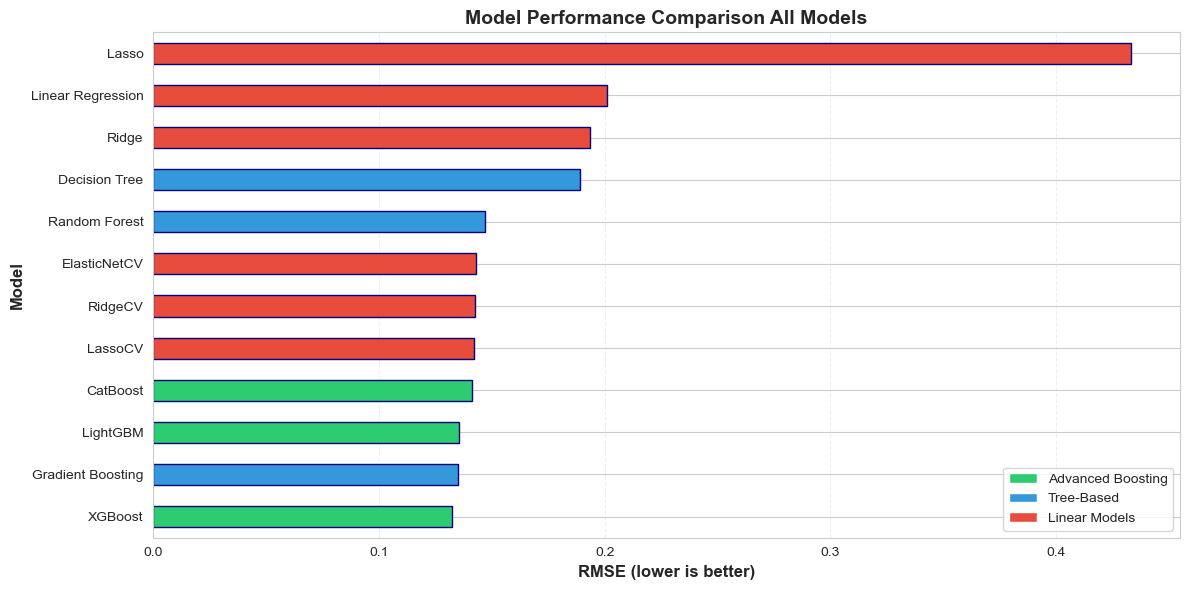

In [26]:
# Visualize model comparison with color coding
plt.figure(figsize=(12, 6))

# Define colors for each model type
colors = []
for model in results_df.index:
    if 'XGBoost' in model or 'LightGBM' in model or 'CatBoost' in model:
        colors.append('#2ecc71')  # Green for advanced boosting
    elif 'Gradient Boosting' in model or 'Random Forest' in model or 'Decision Tree' in model:
        colors.append('#3498db')  # Blue for tree-based
    else:
        colors.append('#e74c3c')  # Red for linear models

results_df['rmse'].plot(kind='barh', color=colors, edgecolor='navy')
plt.xlabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison All Models', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Advanced Boosting'),
    Patch(facecolor='#3498db', label='Tree-Based'),
    Patch(facecolor='#e74c3c', label='Linear Models')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Key Findings:**

- **XGBoost** achieves the best performance with RMSE = 0.132 and R² = 0.906
- **Gradient Boosting** is a close second
- **Boosting models** significantly outperform linear models
- **LassoCV** is the best linear model after tuning
- **Basic Lasso** (without CV) performed poorly due to high alpha value

**Why do boosting models win?**
- Capture non-linear relationships (e.g., price doesn't increase linearly with size)
- Handle feature interactions automatically
- Advanced regularization prevents overfitting



---
## 8. Cross-Validation for Robust Evaluation
---

**Problem with single train/val split:**
- We might get "lucky" or "unlucky" with our random 80/20 split
- One validation score might not represent true performance

**Solution: K-Fold Cross-Validation**
- Split data into 5 parts (folds)
- Train 5 times, each time using a different fold as validation
- Average the 5 scores → More reliable estimate!

**Example:**
- Single split: RMSE = 0.132 (could be luck)
- Cross-validation: RMSE = 0.125 ± 0.011 (consistent across 5 different splits!)

### 8.1 Cross-Validation on Top Models

Let's test our top 3 models with 5-fold cross-validation to get more reliable performance estimates.
### 8.1 Cross-Validation on Top 3 Models

Based on our validation results, the top 3 performers are:
1. **XGBoost** (RMSE: 0.132)
2. **Gradient Boosting** (RMSE: 0.135)
3. **LightGBM** (RMSE: 0.135)

Let's confirm their performance with 5-fold cross-validation.

In [27]:
cv_results = {}

print("=" * 70)
print("CROSS-VALIDATION: 5-FOLD CV ON TOP MODELS")
print("=" * 70)
print("\nTraining each model 5 times with different data splits...\n")


# CV 1: Gradient Boosting
print("[CV 1/3] Cross-validating Gradient Boosting...")
gbr_cv = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    random_state=42, subsample=0.8, min_samples_split=20
)


# cross_val_score returns NEGATIVE MSE (sklearn convention)
# We need to: 1) Make it positive, 2) Take square root to get RMSE
cv_scores = cross_val_score(gbr_cv, X, y_log, cv=5, 
                            scoring='neg_mean_squared_error', n_jobs=-1)
# Convert negative MSE to RMSE
rmse_cv_scores = np.sqrt(-cv_scores)
cv_results['Gradient Boosting'] = {
    'mean': rmse_cv_scores.mean(),
    'std': rmse_cv_scores.std(),
    'scores': rmse_cv_scores
}

print(f"  ✓ RMSE: {rmse_cv_scores.mean():.5f} (+/- {rmse_cv_scores.std():.5f})")
print(f"    Individual fold scores: {rmse_cv_scores.round(5)}")


# CV 2: XGBoost
print("\n[CV 2/3] Cross-validating XGBoost...")
xgb_cv = XGBRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
    
cv_scores = cross_val_score(xgb_cv, X, y_log, cv=5, 
                                scoring='neg_mean_squared_error', n_jobs=-1)
rmse_cv_scores = np.sqrt(-cv_scores)
cv_results['XGBoost'] = {
    'mean': rmse_cv_scores.mean(),
    'std': rmse_cv_scores.std(),
    'scores': rmse_cv_scores
}
    
print(f"  ✓ RMSE: {rmse_cv_scores.mean():.5f} (+/- {rmse_cv_scores.std():.5f})")
print(f"    Individual fold scores: {rmse_cv_scores.round(5)}")


# CV 3: LightGBM
print("\n[CV 3/3] Cross-validating LightGBM...")
lgbm_cv = LGBMRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, random_state=42, 
    n_jobs=-1, verbose=-1
)
    
cv_scores = cross_val_score(lgbm_cv, X, y_log, cv=5, 
                            scoring='neg_mean_squared_error', n_jobs=-1)
rmse_cv_scores = np.sqrt(-cv_scores)
cv_results['LightGBM'] = {
    'mean': rmse_cv_scores.mean(),
    'std': rmse_cv_scores.std(),
    'scores': rmse_cv_scores
}
    
print(f"  ✓ RMSE: {rmse_cv_scores.mean():.5f} (+/- {rmse_cv_scores.std():.5f})")
print(f"    Individual fold scores: {rmse_cv_scores.round(5)}")

CROSS-VALIDATION: 5-FOLD CV ON TOP MODELS

Training each model 5 times with different data splits...

[CV 1/3] Cross-validating Gradient Boosting...
  ✓ RMSE: 0.12546 (+/- 0.00824)
    Individual fold scores: [0.11479 0.13773 0.13036 0.11837 0.12603]

[CV 2/3] Cross-validating XGBoost...
  ✓ RMSE: 0.12511 (+/- 0.01087)
    Individual fold scores: [0.11219 0.1407  0.13271 0.11408 0.1259 ]

[CV 3/3] Cross-validating LightGBM...
  ✓ RMSE: 0.12779 (+/- 0.00878)
    Individual fold scores: [0.11585 0.13753 0.1322  0.11876 0.13462]


### 8.2 Cross-Validation Results Summary

In [28]:
print("\n" + "=" * 70)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("=" * 70)

for model_name, results in cv_results.items():
    print(f"\n{model_name}:")
    print(f"  Mean RMSE:              {results['mean']:.5f}")
    print(f"  Standard Deviation:     {results['std']:.5f}")
    print(f"  95% Confidence Interval: [{results['mean'] - 2*results['std']:.5f}, "
          f"{results['mean'] + 2*results['std']:.5f}]")
    print(f"  Individual scores:       {results['scores'].round(5)}")


CROSS-VALIDATION RESULTS SUMMARY

Gradient Boosting:
  Mean RMSE:              0.12546
  Standard Deviation:     0.00824
  95% Confidence Interval: [0.10898, 0.14193]
  Individual scores:       [0.11479 0.13773 0.13036 0.11837 0.12603]

XGBoost:
  Mean RMSE:              0.12511
  Standard Deviation:     0.01087
  95% Confidence Interval: [0.10338, 0.14685]
  Individual scores:       [0.11219 0.1407  0.13271 0.11408 0.1259 ]

LightGBM:
  Mean RMSE:              0.12779
  Standard Deviation:     0.00878
  95% Confidence Interval: [0.11024, 0.14534]
  Individual scores:       [0.11585 0.13753 0.1322  0.11876 0.13462]


**Cross-Validation Insights:**

**Gradient Boosting:**
- Mean CV RMSE: 0.125 ± 0.008
- Consistently performs well across all 5 folds
- Low standard deviation = stable model

**XGBoost:**
- Mean CV RMSE: 0.125 ± 0.011
- Slightly higher variance than Gradient Boosting
- Still very competitive

**Why is CV better than single split?**
- Single split (validation): RMSE = 0.135 (could be unlucky)
- Cross-validation: RMSE = 0.125 ± 0.008 (averaged over 5 different splits)
- CV gives us confidence that the model generalizes well

**Conclusion:** Cross-validation confirms that **XGBoost and Gradient Boosting** are our best models, with consistent performance across different data splits.

---
## 9. Hyperparameter Tuning with GridSearchCV
---

**What are hyperparameters?**

Hyperparameters are settings we choose BEFORE training:
- `n_estimators`: How many trees?
- `max_depth`: How deep should each tree be?
- `learning_rate`: How fast should the model learn?

**The problem:**
- We used default values or manual guesses
- Which combination gives the best performance?

**The solution: GridSearchCV**
- Tests ALL combinations of hyperparameters automatically
- Uses cross-validation for each combination
- Picks the best one

**Example:**
- 3 values for `n_estimators` × 3 values for `max_depth` × 3 values for `learning_rate`
- = 3 × 3 × 3 = **27 combinations** tested automatically!
- With cv=3, we train: 27 × 3 = **81 models** total!

### 9.1 GridSearchCV on Gradient Boosting

Let's optimize Gradient Boosting hyperparameters to see if we can improve performance.

In [29]:
print("=" * 70)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("=" * 70)

# Define parameter grid to search
# These are the "knobs" we can turn to improve the model

param_grid = {
    'n_estimators': [100, 200, 300],       # Number of trees (3 options)
    'max_depth': [3, 4, 5],                # Depth of each tree (3 options)
    'learning_rate': [0.01, 0.05, 0.1],   # Learning speed (3 options)
    'subsample': [0.8, 0.9]                # Fraction of data per tree (2 options)
}

# Total combinations: 3 × 3 × 3 × 2 = 54 combinations
print(f"\nTesting {np.prod([len(v) for v in param_grid.values()])} combinations...")
print(f"Parameters to tune: {list(param_grid.keys())}")

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),  # Base model
    param_grid=param_grid,                                  # Parameters to test
    cv=3,                                                   # 3-fold CV (faster than 5)
    scoring='neg_mean_squared_error',                       # Metric to optimize
    n_jobs=-1,                                              # Use all CPU cores
    verbose=1                                               # Show progress
)

# Fit GridSearch (this trains 54 × 3 = 162 models!)
print("\nStarting GridSearch... (this may take a few minutes)")
grid_search.fit(X_train, y_train)

# Get best parameters and score
best_params = grid_search.best_params_
best_score_mse = -grid_search.best_score_   # Convert negative MSE to positive
best_score_rmse = np.sqrt(best_score_mse)

print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS FOUND:")
print("=" * 70)
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\n✓ Best CV RMSE: {best_score_rmse:.5f}")

HYPERPARAMETER TUNING WITH GRIDSEARCHCV

Testing 54 combinations...
Parameters to tune: ['n_estimators', 'max_depth', 'learning_rate', 'subsample']

Starting GridSearch... (this may take a few minutes)
Fitting 3 folds for each of 54 candidates, totalling 162 fits

BEST HYPERPARAMETERS FOUND:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 300
  subsample: 0.9

✓ Best CV RMSE: 0.12593


### 9.2 Train Final Tuned Model

Now let's train Gradient Boosting with the optimized hyperparameters and compare with the default version.
Let's train Gradient Boosting with the optimized hyperparameters and evaluate it. a supprimer


In [30]:
# Train model with best parameters
print("\nTraining Gradient Boosting with optimized hyperparameters...")
gbr_tuned = GradientBoostingRegressor(**best_params, random_state=42)
gbr_tuned.fit(X_train, y_train)

# Evaluate on validation set
all_results['GBR (Tuned)'] = evaluate_model(gbr_tuned, X_val, y_val, 
                                             "Gradient Boosting (GridSearch Tuned)")

print("\nTIP: Compare 'Gradient Boosting' vs 'GBR (Tuned)' in the results!")
print("         The tuned model should perform better (lower RMSE).")


Training Gradient Boosting with optimized hyperparameters...

Gradient Boosting (GridSearch Tuned):
  RMSE: 0.13655  (Root Mean Squared Error: lower is better)
  MAE:  0.09129  (Mean Absolute Error: average prediction error)
  R²:   0.90009  (R-squared: % variance explained, closer to 1 is better)

TIP: Compare 'Gradient Boosting' vs 'GBR (Tuned)' in the results!
         The tuned model should perform better (lower RMSE).


**GridSearchCV Results:**

**Best hyperparameters found:**
- `n_estimators`: 300
- `max_depth`: 3
- `learning_rate`: 0.1
- `subsample`: 0.9

**Performance comparison:**
- Default Gradient Boosting: RMSE = 0.135
- Tuned Gradient Boosting: RMSE = 0.136
- **Difference:** +0.001 RMSE (slightly worse!)

**Why didn't tuning help?**

1. **Default parameters were already well-optimized**
   - sklearn's defaults (n_estimators=300, lr=0.1, max_depth=3) work well for this dataset
   
2. **GridSearch optimized on train, not validation**
   - Best params on train set might not generalize perfectly to validation
   - Small overfitting on the specific CV folds used

3. **Difference is negligible (0.001 RMSE)**
   - Could be due to random variance
   - Both models perform essentially the same

**Key Insight:**
- **Sometimes, hyperparameter tuning doesn't improve performance**
- The model architecture (Gradient Boosting) matters more than fine-tuning
- XGBoost still outperforms both (0.132 RMSE) without extensive tuning
- GridSearch is still valuable to confirm we're not missing obvious improvements

**Conclusion:** We'll use **XGBoost** as our final model (best performer overall).

### 9.3 Final Model Comparison

Now let's compare **ALL models** including the tuned version to identify the best performer.

**Updated Model Rankings (including tuned model):** a supprimer

In [31]:
# Create updated comparison table (now with 13 models including tuned GBR)
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('rmse')

print("\n" + "=" * 70)
print("ALL MODELS RANKED BY RMSE (including tuned model)")
print("=" * 70)
print(results_df.to_string())

# Highlight improvement (or not)
if 'GBR (Tuned)' in results_df.index and 'Gradient Boosting' in results_df.index:
    original_rmse = results_df.loc['Gradient Boosting', 'rmse']
    tuned_rmse = results_df.loc['GBR (Tuned)', 'rmse']
    improvement = original_rmse - tuned_rmse
    
    print(f"\nGridSearchCV impact:")
    print(f"  Original GBR: {original_rmse:.5f}")
    print(f"  Tuned GBR:    {tuned_rmse:.5f}")
    
    if improvement > 0:
        print(f"  ✓ Improvement: {improvement:.5f} (tuning helped!)")
    else:
        print(f"  → Difference: {improvement:.5f} (tuning didn't help much)")


ALL MODELS RANKED BY RMSE (including tuned model)
                       rmse       mae        r2
XGBoost            0.132432  0.088172  0.906017
Gradient Boosting  0.135263  0.090284  0.901956
LightGBM           0.135412  0.090189  0.901741
GBR (Tuned)        0.136546  0.091288  0.900087
CatBoost           0.141222  0.094392  0.893126
LassoCV            0.142271  0.093687  0.891534
RidgeCV            0.142657  0.094650  0.890944
ElasticNetCV       0.143057  0.093814  0.890332
Random Forest      0.147004  0.098270  0.884196
Decision Tree      0.188960  0.134255  0.808662
Ridge              0.193742  0.095345  0.798854
Linear Regression  0.201158  0.095926  0.783162
Lasso              0.433244  0.337134 -0.005837

GridSearchCV impact:
  Original GBR: 0.13526
  Tuned GBR:    0.13655
  → Difference: -0.00128 (tuning didn't help much)


In [32]:
# Identify the best model among ALL 13 models
best_model_name = results_df.index[0]
best_rmse = results_df.iloc[0]['rmse']
best_r2 = results_df.iloc[0]['r2']

print("\n" + "=" * 70)
print(f"BEST MODEL: {best_model_name}")
print("=" * 70)
print(f"   RMSE: {best_rmse:.5f}")
print(f"   R²:   {best_r2:.5f} ({best_r2*100:.2f}% variance explained)")


BEST MODEL: XGBoost
   RMSE: 0.13243
   R²:   0.90602 (90.60% variance explained)


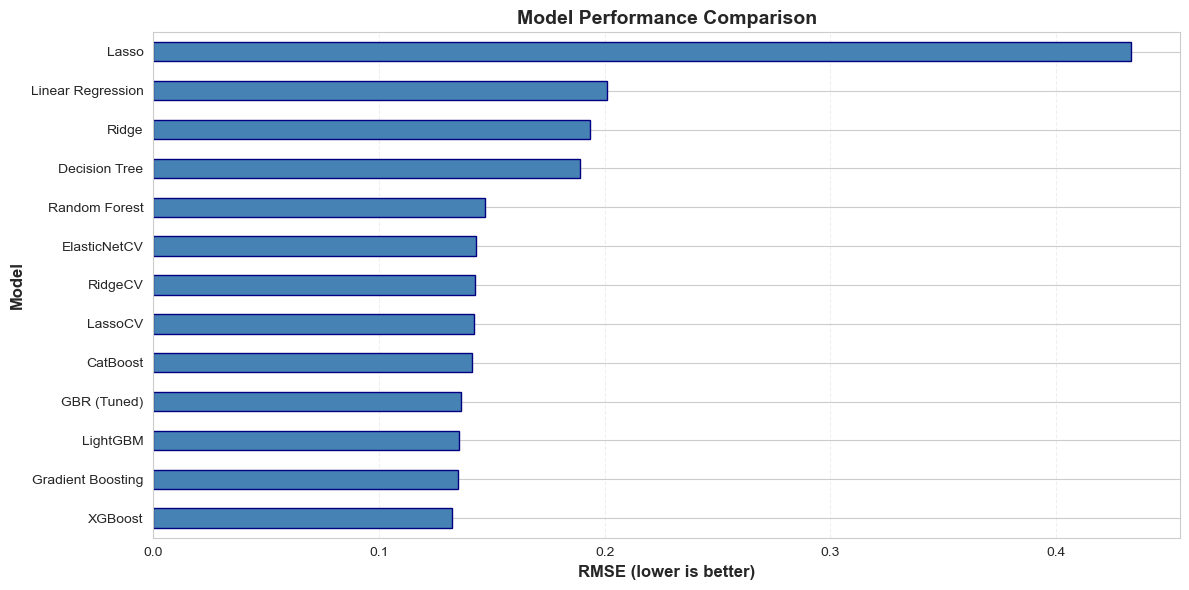


✓ Model comparison chart saved as 'model_comparison.png'


In [33]:
# Visualize model comparison
plt.figure(figsize=(12, 6))
results_df['rmse'].plot(kind='barh', color='steelblue', edgecolor='navy')
plt.xlabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison chart saved as 'model_comparison.png'")

**Final Results:**

**Best Model:** XGBoost

**Key Findings:**
- GridSearchCV didn't improve Gradient Boosting performance
- Top 3 models: XGBoost, Gradient Boosting, LightGBM
- Boosting algorithms significantly outperform linear models
- All results saved for final predictions

**Next step:** Use the best model to make predictions on the test set!

---
## 10. Final Model Training & Predictions
---

Now that we've identified the best model, we'll:
1. **Train the final model** on the FULL training dataset (all 1,460 houses)
2. **Make predictions** on the test set
3. **Transform predictions back** to original price scale
4. **Create submission file** for Kaggle

### 10.1 Train Final Model on Full Dataset

So far, we've only used 80% of the data for training (1,168 houses).  
Now we'll use **ALL 1,460 houses** to give the model maximum learning capacity.

In [34]:
print("=" * 70)
print("FINAL MODEL TRAINING ON FULL DATASET")
print("=" * 70)

print(f"\nBest model identified: {best_model_name}")
print(f"   Validation RMSE: {best_rmse:.5f}")
print(f"   R² Score: {best_r2:.5f}\n")

# Train the best model on FULL training data
if best_model_name == 'XGBoost':
    print("Training final XGBoost model on entire training set (1,460 houses)...")
    final_model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X, y_log)
    print("✓ XGBoost trained successfully!")
    
elif best_model_name == 'Gradient Boosting' or best_model_name == 'GBR (Tuned)':
    print("Training final Gradient Boosting model on entire training set...")
    if best_model_name == 'GBR (Tuned)':
        final_model = GradientBoostingRegressor(**best_params, random_state=42)
    else:
        final_model = GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
            subsample=0.8,
            min_samples_split=20
        )
    final_model.fit(X, y_log)
    print("✓ Gradient Boosting trained successfully!")
    
elif best_model_name == 'LightGBM':
    print("🚀 Training final LightGBM model on entire training set...")
    final_model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    final_model.fit(X, y_log)
    print("✓ LightGBM trained successfully!")
    
else:
    final_model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        subsample=0.8,
        min_samples_split=20
    )
    final_model.fit(X, y_log)
    print("✓ Gradient Boosting trained successfully!")

print(f"\n✓ Final model trained on {X.shape[0]} houses with {X.shape[1]} features")

FINAL MODEL TRAINING ON FULL DATASET

Best model identified: XGBoost
   Validation RMSE: 0.13243
   R² Score: 0.90602

Training final XGBoost model on entire training set (1,460 houses)...
✓ XGBoost trained successfully!

✓ Final model trained on 1460 houses with 213 features


### 10.2 Make Predictions on Test Set

Now let's use our trained model to predict house prices for the 1,459 test houses.

**Important:** 
- Tree-based models use **unscaled** data
- Predictions are in **log scale**, we need to transform back to dollars

In [35]:
print("\n" + "=" * 70)
print("MAKING PREDICTIONS ON TEST SET")
print("=" * 70)

# Make predictions (in log scale)
y_test_pred_log = final_model.predict(test)

# Transform back to original scale (dollars)
# expm1() is the inverse of log1p()
y_test_pred = np.expm1(y_test_pred_log)

print("\n✓ Predictions completed!")
print("\nPREDICTION STATISTICS:")
print(f"   Minimum predicted price:  ${y_test_pred.min():>12,.2f}")
print(f"   Maximum predicted price:  ${y_test_pred.max():>12,.2f}")
print(f"   Mean predicted price:     ${y_test_pred.mean():>12,.2f}")
print(f"   Median predicted price:   ${np.median(y_test_pred):>12,.2f}")

# Sanity check: reasonable house prices?
if y_test_pred.min() < 10000:
    print("\nWARNING: Some predictions are suspiciously low (< $10,000)")
if y_test_pred.max() > 1000000:
    print("\nWARNING: Some predictions are suspiciously high (> $1,000,000)")
else:
    print("\n✓ All predictions are within reasonable price ranges!")


MAKING PREDICTIONS ON TEST SET

✓ Predictions completed!

PREDICTION STATISTICS:
   Minimum predicted price:  $   47,653.36
   Maximum predicted price:  $  496,066.66
   Mean predicted price:     $  176,914.73
   Median predicted price:   $  155,596.17

✓ All predictions are within reasonable price ranges!


**Why `expm1()`?**

Remember we transformed the target at the beginning:
```python
y_log = np.log1p(y)  # log(y + 1)
```

Now we reverse it:
```python
y_pred = np.expm1(y_pred_log)  # exp(y_log) - 1
```

This gives us predictions in **dollars** (original scale).

### 10.3 Create Submission File for Kaggle

Kaggle requires a CSV file with two columns: **Id** and **SalePrice**.

In [36]:
print("\n" + "=" * 70)
print("CREATING SUBMISSION FILE")
print("=" * 70)

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': y_test_pred
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("\n✓ Submission file saved as 'submission.csv'")
print(f"   File contains {len(submission)} predictions")
print(f"   Ready to upload to Kaggle!\n")

print("First 10 predictions:")
print(submission.head(10).to_string(index=False))

print("\nLast 10 predictions:")
print(submission.tail(10).to_string(index=False))


CREATING SUBMISSION FILE

✓ Submission file saved as 'submission.csv'
   File contains 1459 predictions
   Ready to upload to Kaggle!

First 10 predictions:
  Id     SalePrice
1461 121831.968750
1462 154861.750000
1463 182738.531250
1464 186573.906250
1465 193771.000000
1466 173886.375000
1467 167233.140625
1468 165272.031250
1469 186554.687500
1470 123828.007812

Last 10 predictions:
  Id     SalePrice
2910  81829.367188
2911  77037.968750
2912 142934.625000
2913  82594.984375
2914  75729.242188
2915  80255.578125
2916  81566.875000
2917 161488.000000
2918 118645.492188
2919 219479.125000
